# Repliement

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import skimage.io as io
from scipy.io import wavfile
from IPython.display import Audio
from scipy.interpolate import interp1d

mpl.style.use('../src/signal.mplstyle')
mpl.rcParams['font.size'] = 16

## Signal cosinus

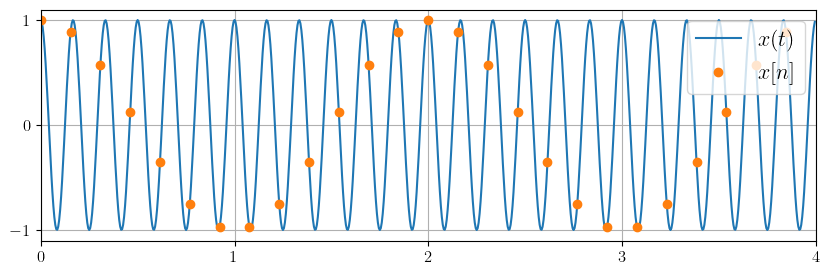

In [2]:
# Paramètres du signal
d = 4
f = 6

# Signal analogique
ta = np.arange(0,d,1/200)
xa = np.cos(2*np.pi*f*ta)

# Signal échantillonné
fe = 6.5
Te = 1/fe
tn = np.arange(0,d,Te)
xn = np.cos(2*np.pi*f*tn)

# Affichage
plt.figure(figsize=(10,3))
plt.plot(ta, xa, label="$x(t)$")
plt.plot(tn, xn, 'o', label="$x[n]$")
plt.xticks(range(0,d+1,1))
plt.yticks(range(-1,2,1))
plt.legend(loc="upper right")
plt.xlim(0,d)
plt.savefig(f"aliasing-signal.svg")
plt.show()

## Signal audio

In [3]:
fe, x = wavfile.read("Elise.wav")
t = np.arange(len(x))/fe
print(f"Fréquence orignale : {fe} Hz")

for D in [1, 10, 20, 30]:

    # Sous-échantillonnage
    fe_new = fe//D
    print(f"Sous échantillonnage à : {fe_new} Hz")
    xd = x[::D]
    td = t[::D]
    
    # Rééchantillonnage à 44 100 Hz
    f = interp1d(td, xd, kind='cubic')
    tu = t[D:-D]
    xu = f(tu)
    xu = xu.astype("int16")
    
    # Enregistrement
    wavfile.write(f"Elise-{fe_new}.wav", fe, xu)
    
# Écoute
Audio(xu, rate=fe)

Fréquence orignale : 44100 Hz
Sous échantillonnage à : 44100 Hz
Sous échantillonnage à : 4410 Hz
Sous échantillonnage à : 2205 Hz
Sous échantillonnage à : 1470 Hz


## Image

In [4]:
img = io.imread("aliasing-moi.jpg")
for x in [4, 5, 6, 9]:
    img_resized = img[::x,::x]
    io.imsave(f"aliasing-moi-{x}.jpg", img_resized)